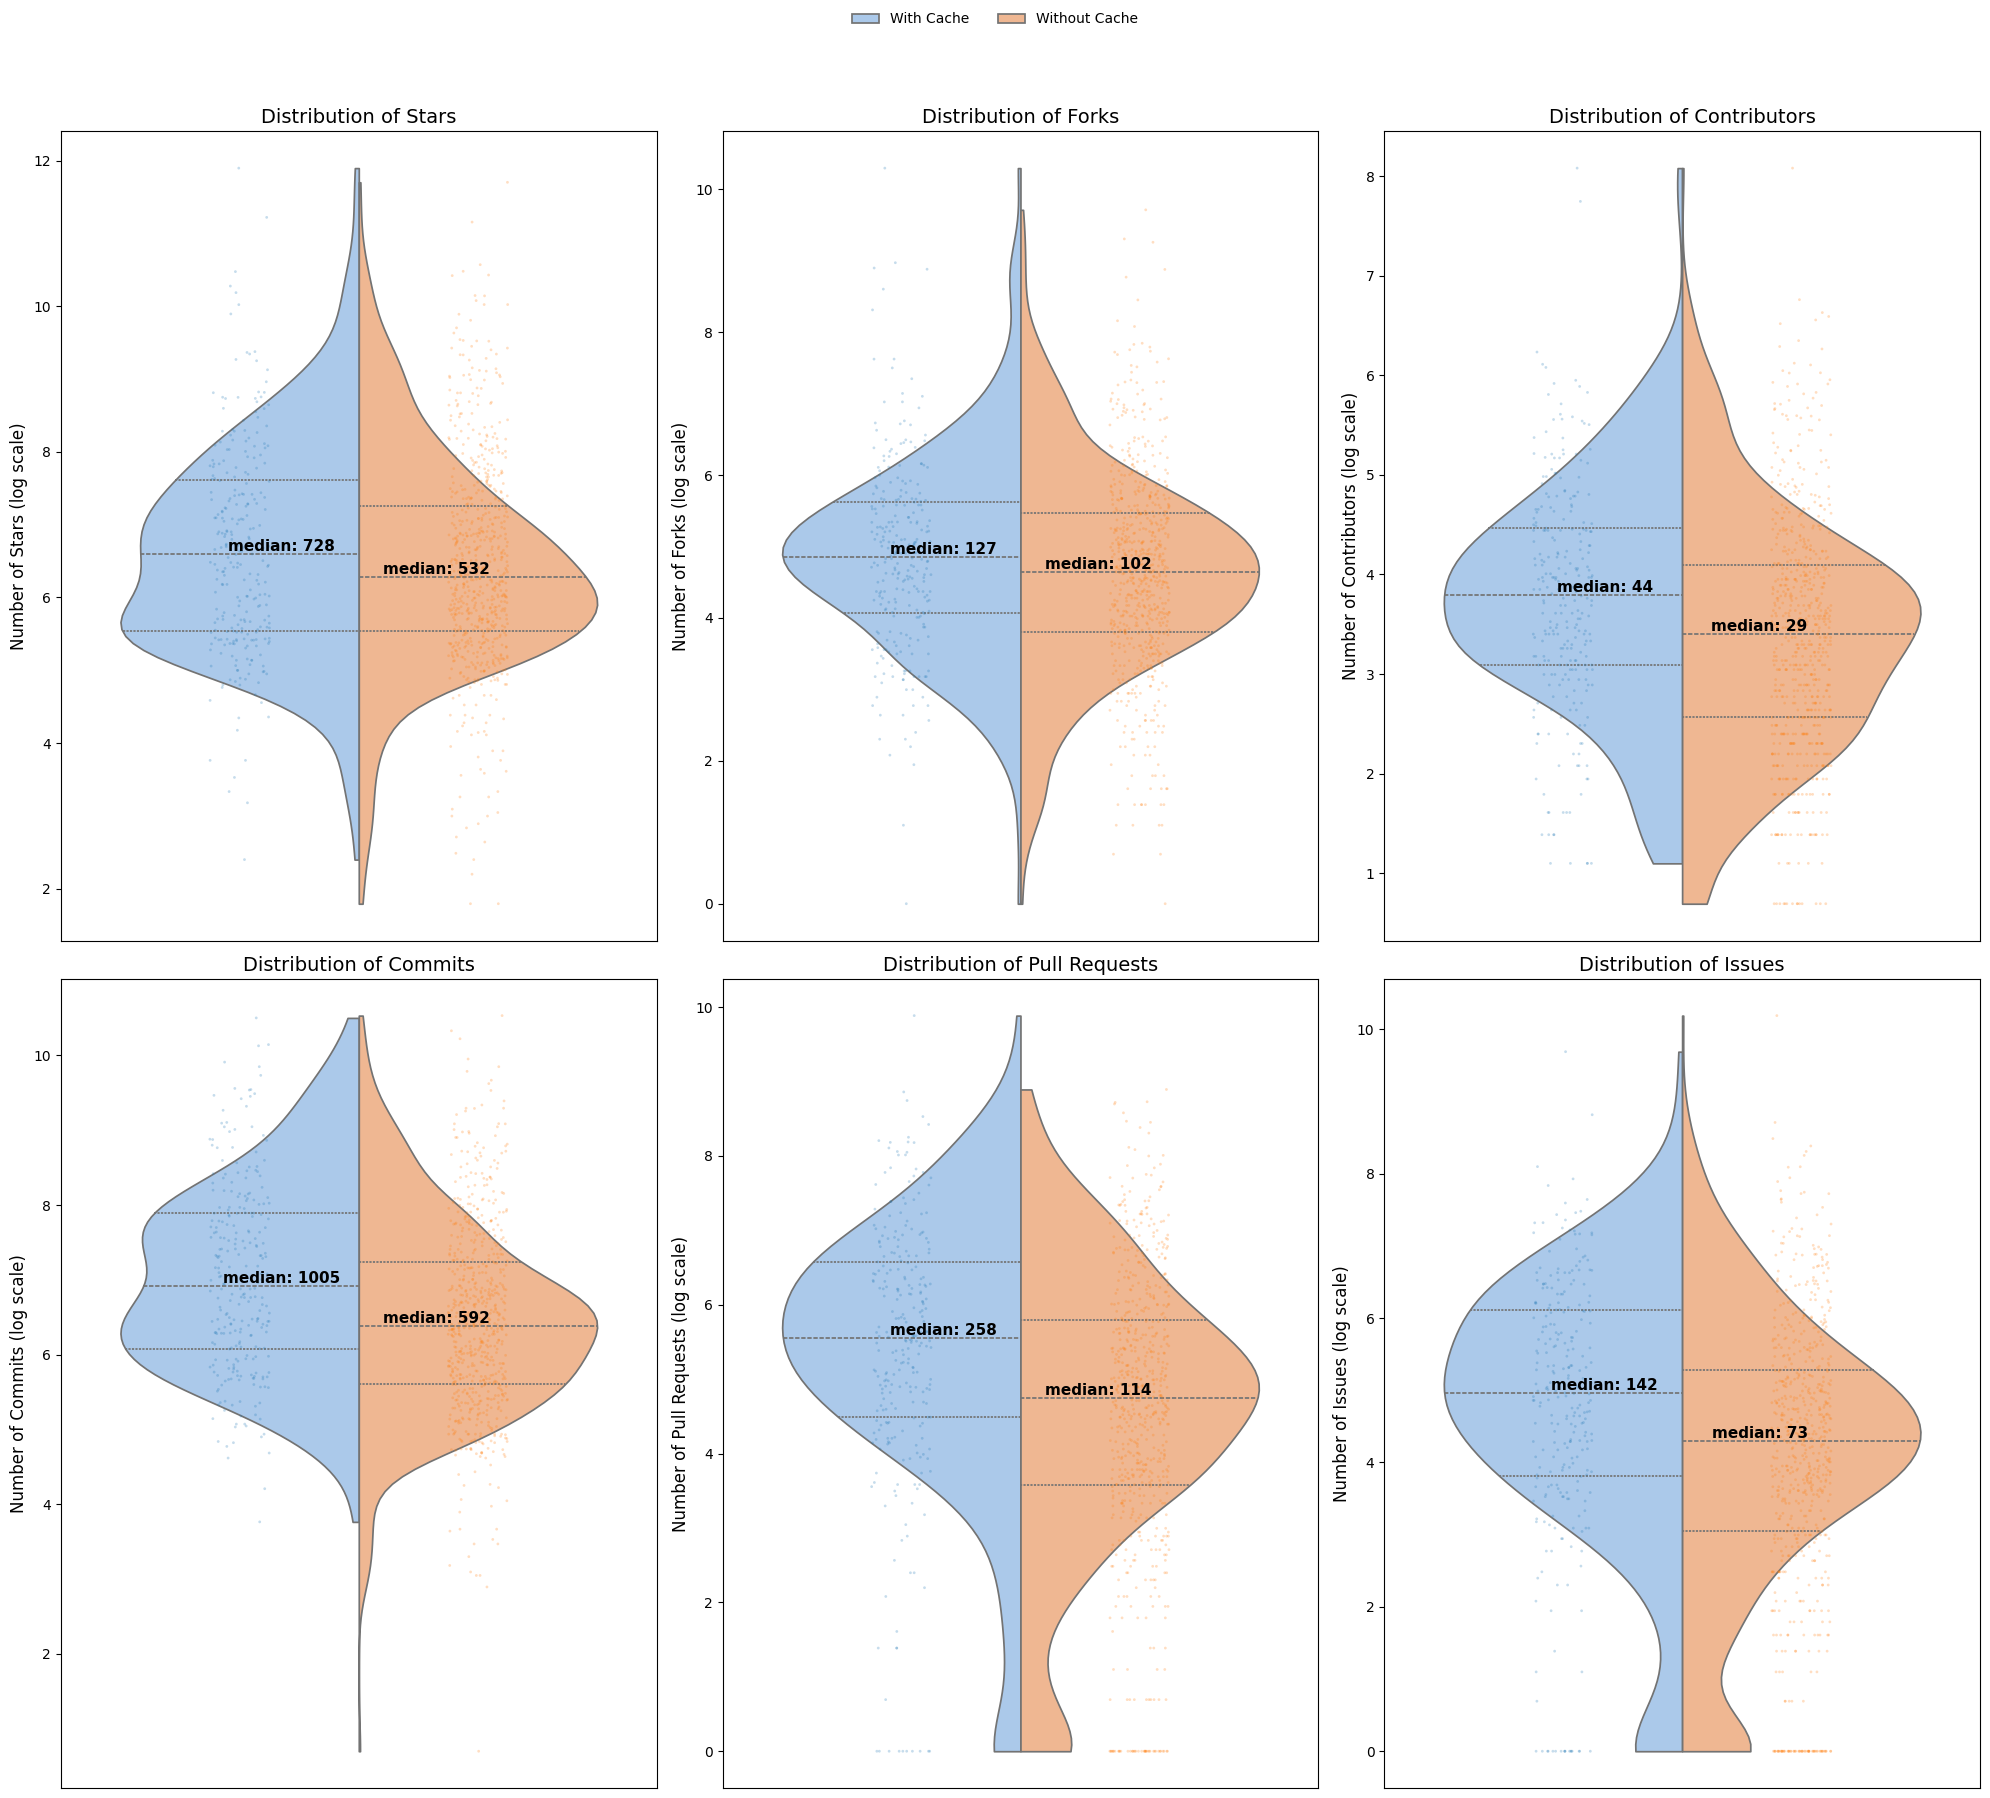

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

repo_with_cache = pd.read_csv('cache_adopted_repos.csv')
repo_without_cache = pd.read_csv('non_cache_adopted_repos.csv')

repo_with_cache['cache_status'] = 'With Cache'
repo_without_cache['cache_status'] = 'Without Cache'
combined_df = pd.concat([repo_with_cache, repo_without_cache], ignore_index=True)

metrics = ['stars', 'forks', 'contributors', 'commits', 'pull_requests', 'issues']

fig, axes = plt.subplots(2, 3, figsize=(20, 18))
axes = axes.flatten()

hue_order = ['With Cache', 'Without Cache']

for ax, metric in zip(axes, metrics):
    plot_df = combined_df[['cache_status', metric]].copy()
    plot_df['x'] = ''  
    plot_df[f'{metric}_log'] = np.log1p(plot_df[metric])

    sns.violinplot(
        x='x',
        y=f'{metric}_log',
        hue='cache_status',
        data=plot_df,
        ax=ax,
        hue_order=hue_order,
        split=True,          
        inner='quartile',
        cut=0,
        palette='pastel'
    )


    sns.stripplot(
        x='x',
        y=f'{metric}_log',
        hue='cache_status',
        data=plot_df,
        ax=ax,
        hue_order=hue_order,
        dodge=True,
        size=2,
        alpha=0.25,
        linewidth=0
    )

    if ax.get_legend() is not None:
        ax.get_legend().remove()

    med_orig = plot_df.groupby('cache_status')[metric].median()

    offsets = {'With Cache': -0.13, 'Without Cache': 0.13}
    for status in hue_order:
        med_val = med_orig.loc[status]
        y = np.log1p(med_val)
        ax.text(
            0 + offsets[status], y,
            f"median: {med_val:.0f}",
            ha='center', va='bottom',
            fontsize=11, fontweight='bold'
        )

    ax.set_title(f'Distribution of {metric.replace("_", " ").title()}', fontsize=14)
    ax.set_xlabel('')
    ax.set_xticks([])  
    ax.set_ylabel(f'Number of {metric.replace("_", " ").title()} (log scale)', fontsize=12)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles[:2], labels[:2], loc='upper center', ncol=2, frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [3]:
repo_with_cache['language'].value_counts()

language
TypeScript    45
Python        42
JavaScript    37
Java          36
PHP           26
Go            22
C++           17
Kotlin        12
C              9
Ruby           6
Shell          4
C#             3
Vue            1
Swift          1
Stylus         1
MDX            1
Solidity       1
SCSS           1
Name: count, dtype: int64

In [4]:
repo_without_cache['language'].value_counts()

language
Python              146
JavaScript          109
TypeScript           79
Go                   54
C++                  52
C#                   38
C                    38
Java                 35
Ruby                 28
PHP                  22
Kotlin               21
Swift                19
Shell                17
Objective-C           4
Jupyter Notebook      4
HTML                  2
Vue                   2
Rust                  2
Cython                1
R                     1
Vala                  1
MDX                   1
CSS                   1
Name: count, dtype: int64

In [5]:
repo_without_cache['language'].value_counts(normalize=True)

language
Python              0.215657
JavaScript          0.161004
TypeScript          0.116691
Go                  0.079764
C++                 0.076809
C#                  0.056130
C                   0.056130
Java                0.051699
Ruby                0.041359
PHP                 0.032496
Kotlin              0.031019
Swift               0.028065
Shell               0.025111
Objective-C         0.005908
Jupyter Notebook    0.005908
HTML                0.002954
Vue                 0.002954
Rust                0.002954
Cython              0.001477
R                   0.001477
Vala                0.001477
MDX                 0.001477
CSS                 0.001477
Name: proportion, dtype: float64

In [6]:
import pandas as pd
from scipy.stats import chi2_contingency

data = [
    ["PHP", 26, 22],
    ["Java", 36, 35],
    ["Kotlin", 12, 21],
    ["TypeScript", 45, 79],
    ["Go", 22, 54],
    ["JavaScript", 37, 109],
    ["C++", 17, 52],
    ["Python", 42, 146],
    ["C", 9, 38],
    ["Shell", 4, 17],
    ["Ruby", 6, 28],
    ["Others", 10, 79]
]

df = pd.DataFrame(data, columns=["Language", "With", "Without"])
contingency = df[["With", "Without"]]

chi2, p, dof, expected = chi2_contingency(contingency)

print("Chi-square:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)

Chi-square: 60.46152998386773
p-value: 7.61024728693282e-09
Degrees of freedom: 11


In [ ]:
import pandas as pd

filtered_full_ga = pd.read_csv("changes.csv")


import pandas as pd

# make sure committed_date is datetime
filtered_full_ga['committed_date'] = pd.to_datetime(filtered_full_ga['committed_date'])

# 1. define your snapshot date (or grab the max)
snapshot_date = pd.to_datetime('2025-05-16')
# snapshot_date = filtered_full_ga['committed_date'].max()

# 2. keep only changes up to that date
df_up_to = filtered_full_ga[filtered_full_ga['committed_date'] <= snapshot_date].copy()

# 3. for each (repo, file_path) get the last change
df_up_to = df_up_to.sort_values(['repository','file_path','committed_date'])
last_changes = (
    df_up_to
      .groupby(['repository','file_path'], as_index=False)
      .last()
)

# 4. drop any file whose last change was a removal (‘R’)
present = last_changes[last_changes['git_change_type'] != 'R']

# 5. now compute your summary exactly as before, but on `present`
repo_counts = (
    present
      .groupby('repository')
      .agg(
        unique_file_paths = ('file_path','nunique'),
        unique_jobs       = ('job',      'nunique')
      )
)

repo_lists = (
    present
      .groupby('repository')
      .agg(
        file_paths = ('file_path', lambda s: list(s.unique())),
        jobs       = ('job',       lambda s: list(s.unique()))
      )
)

repo_summary = repo_counts.join(repo_lists).reset_index()


In [ ]:


from pathlib import Path
import pandas as pd


# Configuration
PATTERNS = ("uses:", "path:")

EXCLUDED_ACTION_HINTS = (
    "actions/checkout",
    "actions/upload-artifact",
    "actions/download-artifact",
    "actions/upload-release-asset",
)

JOB_KEYWORDS = {
    "build": [
        "build", "compile", "assemble", "install", "package", "phar",
        "prepare", "run", "emscripten", "gauzy-webapp", "gauzy-api",
        "docker-push", "rpm", "deb", "get_runner", "develop",
        "deploy-website", "deploy-flat-web-dev", "gradle", "setup"
    ],
    "test": [
        "test", "unit", "e2e", "functional", "regression", "cypress-run",
        "verify", "check", "phpunit", "r-cmd-check", "validation",
        "performance", "check-package", "typecheck", "demo-scripts",
        "validate", "validate_version_bumps"
    ],
    "release": [
        "release", "publish", "publish-npm", "publish-java-sdk", "deploy",
        "push", "publish_archives", "deploy_to_npm", "deploy_to_firebase",
        "deploy-snapshot", "push_to_registry"
    ],
    "analyze": [
        "analyze", "static-analysis", "codacy-coverage-reporter",
        "gradle-dependency-detection", "license-checks", "checks",
        "check_runners", "analysis", "clang-tidy", "clang-debug",
        "cppcheck", "phpcs", "php-cs-fixer", "security-scan",
        "ts-check", "node-checks", "style-check", "phpstan",
        "rubocop", "psalm", "misspell", "finalize-percy",
        "check-code", "typecheck", "shellcheck", "coverage",
        "mirror", "report"
    ],
    "integration": [
        "integration", "e2e-deploy-macos", "e2e-deploy-windows",
        "run_models_gpu", "run_torch_cuda_extensions_gpu",
        "run_quantization_torch_gpu", "run_pipelines_torch_gpu",
        "run_pipelines_tf_gpu", "run_examples_gpu",
        "run_trainer_and_fsdp_gpu", "ci"
    ],
    "sync": [
        "sync", "fetch-dependencies", "update-gradle-wrapper",
        "update_phpstorm_meta", "update_copyright",
        "post-update", "clean", "mutate", "update", "rebase"
    ],
    "lint": ["lint"],
    "linux": ["linux", "ubuntu"],
}

PACKAGE_MANAGER_ACTIONS = (
    "actions/setup-node",
    "actions/setup-python",
    "actions/setup-java",
    "actions/setup-ruby",
    "actions/setup-go",
    "actions/setup-dotnet",
)

DOCKER_CACHE_ACTIONS = (
    "docker/build-push-action",
    "docker/setup-buildx-action",
    "action/docker",
)


# Path resolution
def resolve_package_root() -> Path:
    script_dir = Path(__file__).resolve().parent
    candidates = [script_dir, script_dir.parent]

    for candidate in candidates:
        data_dir = candidate / "data"
        workflows_dir = candidate / "workflows"
        if data_dir.exists() and workflows_dir.exists():
            return candidate

    raise FileNotFoundError(
        "Could not locate the replication package root.\n"
        "Make sure this script is placed either:\n"
        "1) at the package root, or\n"
        "2) inside a scripts/ folder under the package root,\n"
        "and that data/ and workflows/ exist."
    )




PACKAGE_ROOT = resolve_package_root()
DATA_DIR = PACKAGE_ROOT / "data"
WORKFLOWS_DIR = PACKAGE_ROOT / "workflows"
OUTPUT_DIR = PACKAGE_ROOT / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DIFFS_CSV = DATA_DIR / "full_data_ga.csv"
REPOS_TO_KEEP_CSV = DATA_DIR / "df_with_cache_information.csv"


# Helpers
def build_hash_to_path_mapping(workflows_dir: Path) -> dict:
    hash_to_path = {}

    for file_path in workflows_dir.rglob("*"):
        if file_path.is_file():
            hash_to_path[file_path.stem] = file_path

    return hash_to_path


def load_inputs(diffs_csv: Path, repos_csv: Path) -> pd.DataFrame:

    diffs_df = pd.read_csv(diffs_csv)
    repos_to_keep = pd.read_csv(repos_csv)

    keep_list = repos_to_keep["repository"].dropna().unique()
    diffs_df = diffs_df[diffs_df["repository"].isin(keep_list)].copy()

    diffs_df["committed_date"] = pd.to_datetime(diffs_df["committed_date"], errors="coerce")
    diffs_df["current_file"] = diffs_df["current_file"].fillna("").astype(str).str.strip()
    diffs_df["file_path"] = diffs_df["file_path"].fillna("").astype(str).str.strip()
    diffs_df["job"] = diffs_df["job"].fillna("").astype(str).str.strip()

    diffs_df = diffs_df[
        (diffs_df["current_file"] != "") &
        (diffs_df["file_path"] != "") &
        diffs_df["committed_date"].notna()
    ].copy()

    diffs_df.sort_values(["repository", "file_path", "committed_date"], inplace=True)

    return diffs_df


def get_file_content(file_hash: str, hash_to_path: dict, cache: dict) -> str | None:
    if file_hash in cache:
        return cache[file_hash]

    path = hash_to_path.get(file_hash)

    if path is None:
        matches = [k for k in hash_to_path if k.startswith(str(file_hash)[:10])]
        if not matches:
            return None
        path = hash_to_path[matches[0]]

    try:
        content = path.read_text(encoding="utf-8", errors="ignore")
        cache[file_hash] = content
        return content
    except Exception as exc:
        print(f"Could not read {path}: {exc}")
        return None


def extract_pattern_block(content: str, pattern_line: int) -> str:
    lines = content.split("\n")

    start_idx = pattern_line
    for i in range(pattern_line, -1, -1):
        if lines[i].lstrip().startswith("-"):
            start_idx = i
            break

    current_indent = len(lines[start_idx]) - len(lines[start_idx].lstrip())
    end_idx = len(lines) - 1

    for j in range(start_idx + 1, len(lines)):
        line = lines[j]
        indent = len(line) - len(line.lstrip())
        if line.lstrip().startswith("-") and indent <= current_indent:
            end_idx = j - 1
            break

    return "\n".join(lines[start_idx:end_idx + 1]).strip()


def find_all_pattern_blocks(file_content: str) -> list[dict]:
    blocks = []
    lines = file_content.split("\n")

    for idx, line in enumerate(lines):
        stripped = line.lstrip()
        if not stripped or stripped.startswith("#"):
            continue

        lowered = stripped.lower()

        if any(hint in lowered for hint in EXCLUDED_ACTION_HINTS):
            continue

        if any(pattern in lowered for pattern in PATTERNS):
            block = extract_pattern_block(file_content, idx)
            blocks.append({
                "line_number": idx,
                "pattern_line": stripped,
                "block": block,
            })

    return blocks


def extract_job_name(content: str, line_number: int) -> str:
    lines = content.split("\n")
    current_indent = float("inf")
    job_name = ""

    for i in range(line_number, -1, -1):
        stripped = lines[i].strip()

        if not stripped:
            continue
        if stripped == "jobs:":
            break

        if ":" in lines[i] and not stripped.startswith("-"):
            indent = len(lines[i]) - len(lines[i].lstrip())
            if indent < current_indent:
                job_name = stripped.split(":", 1)[0].strip()
                current_indent = indent

    return job_name


def categorize_job(job_name: str) -> str:
    lowered = str(job_name).lower()

    for category, keywords in JOB_KEYWORDS.items():
        for keyword in keywords:
            if keyword in lowered:
                return category

    return "other"



import re

SETUP_GO_DEFAULT_CACHE_RE = re.compile(
    r"(^|\s)actions/setup-go@\s*v(?:4|5|6)(?:\D|$)",
    re.I
)

def categorize_cache(block: str) -> str | None:
    if not isinstance(block, str):
        return None

    s = block.lower().strip()
    if not s:
        return None

    # Explicit cache action
    if "actions/cache@" in s or "uses: actions/cache" in s:
        return "Explicit Caching"

    # Setup Go:
    # v4/v5/v6 => cache enabled by default
    # other versions => require explicit cache:
    if "actions/setup-go@" in s:
        if SETUP_GO_DEFAULT_CACHE_RE.search(s):
            return "Package Manager Caching"
        if "cache:" in s:
            return "Package Manager Caching"
        return None

    # Setup Node:
    # package-manager-cache: true OR cache:
    # but not when package-manager-cache: false
    if "actions/setup-node@" in s:
        if "package-manager-cache: true" in s:
            return "Package Manager Caching"
        if "cache:" in s and "package-manager-cache: false" not in s:
            return "Package Manager Caching"
        return None

    # Setup Python / Java require explicit cache:
    if "actions/setup-python@" in s and "cache:" in s:
        return "Package Manager Caching"

    if "actions/setup-java@" in s and "cache:" in s:
        return "Package Manager Caching"

    # Setup Ruby
    if "actions/setup-ruby@" in s:
        if "cache:" in s or "bundler-cache: true" in s:
            return "Package Manager Caching"
        return None

    # Your RQ2 logic treated ruby/setup-ruby@ as cache-related
    if "ruby/setup-ruby@" in s:
        return "Package Manager Caching"

    # Docker layer caching
    # Keep this only if you still want Docker counted in the table.
    if (
        "docker/build-push-action@" in s
        or "uses: docker/build-push-action" in s
        or "docker/setup-buildx-action@" in s
        or "uses: docker/setup-buildx-action" in s
        or "action/docker" in s
    ):
        if "cache-from" in s or "cache-to" in s:
            return "Docker Layer Caching"
        return None

    # Fallback for cache-related blocks that do not match the main patterns
    if "cache" in s:
        return "Others"

    return None


def format_percent(value: float, decimals: int = 2) -> str:
    return f"{value:.{decimals}f}%"


def format_count_and_percent(count: int, total: int, decimals: int = 1) -> str:
    pct = 0.0 if total == 0 else (count / total) * 100
    return f"{int(count)} ({pct:.{decimals}f}%)"


def collect_latest_workflow_blocks(diffs_df: pd.DataFrame, hash_to_path: dict) -> pd.DataFrame:
    file_content_cache = {}
    latest_rows = []

    grouped = diffs_df.groupby(["repository", "file_path"], dropna=False)

    for (repo, file_path), group in grouped:
        group = group.sort_values("committed_date", ascending=False)

        for _, row in group.iterrows():
            content = get_file_content(row["current_file"], hash_to_path, file_content_cache)
            if not content:
                continue

            blocks = find_all_pattern_blocks(content)
            if not blocks:
                continue

            for block_info in blocks:
                latest_rows.append({
                    "repository": repo,
                    "file_path": file_path,
                    "commit_hash": row["commit_hash"],
                    "committed_date": row["committed_date"],
                    "job_name": extract_job_name(content, block_info["line_number"]) or row.get("job", ""),
                    "pattern_line": block_info["pattern_line"],
                    "block": block_info["block"],
                    "file_hash": row["current_file"],
                })
            break

    latest_blocks_df = pd.DataFrame(latest_rows)

    if latest_blocks_df.empty:
        print("No latest workflow blocks were collected.")
        return latest_blocks_df

    latest_blocks_df["job_name"] = latest_blocks_df["job_name"].fillna("").astype(str).str.strip()

    latest_blocks_df = latest_blocks_df.drop_duplicates(
        subset=["repository", "file_path", "commit_hash", "job_name", "block"],
        keep="first"
    ).copy()

    latest_blocks_df["job_type"] = latest_blocks_df["job_name"].apply(categorize_job)
    latest_blocks_df["cache_type"] = latest_blocks_df["block"].apply(categorize_cache)

    return latest_blocks_df


def build_caching_prevalence_output(diffs_df: pd.DataFrame, latest_blocks_df: pd.DataFrame) -> pd.DataFrame:
    latest_jobs_df = (
        diffs_df[diffs_df["job"] != ""]
        .sort_values(["repository", "file_path", "job", "committed_date"])
        .drop_duplicates(subset=["repository", "file_path", "job"], keep="last")
        .copy()
    )

    latest_jobs_df["job_type"] = latest_jobs_df["job"].apply(categorize_job)

    cache_blocks_df = latest_blocks_df[latest_blocks_df["cache_type"].notna()].copy()

    jobs_with_caching_df = (
        cache_blocks_df[["repository", "file_path", "job_name"]]
        .drop_duplicates()
        .copy()
    )
    jobs_with_caching_df["job_type"] = jobs_with_caching_df["job_name"].apply(categorize_job)

    total_jobs = latest_jobs_df.groupby("job_type").size().rename("Total jobs")
    cached_jobs = jobs_with_caching_df.groupby("job_type").size().rename("# of jobs with caching")

    caching_prevalence_df = (
        pd.concat([cached_jobs, total_jobs], axis=1)
        .fillna(0)
        .astype(int)
        .reset_index()
        .rename(columns={"job_type": "CI/CD job types"})
    )

    caching_prevalence_df["Caching prevalence (%)"] = (
        caching_prevalence_df["# of jobs with caching"] /
        caching_prevalence_df["Total jobs"]
    ).fillna(0.0) * 100

    caching_prevalence_df = caching_prevalence_df.sort_values(
        by=["Caching prevalence (%)", "# of jobs with caching", "CI/CD job types"],
        ascending=[False, False, True]
    ).reset_index(drop=True)

    total_cached = int(caching_prevalence_df["# of jobs with caching"].sum())
    total_jobs_count = int(caching_prevalence_df["Total jobs"].sum())
    overall_prevalence = 0.0 if total_jobs_count == 0 else (total_cached / total_jobs_count) * 100

    total_row = pd.DataFrame([{
        "CI/CD job types": "Total",
        "# of jobs with caching": total_cached,
        "Total jobs": total_jobs_count,
        "Caching prevalence (%)": overall_prevalence,
    }])

    caching_prevalence_df = pd.concat([caching_prevalence_df, total_row], ignore_index=True)

    display_df = caching_prevalence_df.copy()
    display_df["Caching prevalence (%)"] = display_df["Caching prevalence (%)"].apply(
        lambda x: format_percent(x, decimals=2)
    )

    return display_df


def build_cache_type_breakdown_output(latest_blocks_df: pd.DataFrame) -> pd.DataFrame:
    cache_blocks_df = latest_blocks_df[latest_blocks_df["cache_type"].notna()].copy()

    count_df = pd.crosstab(
        cache_blocks_df["job_type"],
        cache_blocks_df["cache_type"]
    )

    desired_columns = [
        "Explicit Caching",
        "Package Manager Caching",
        "Docker Layer Caching",
        "Others",
    ]
    count_df = count_df.reindex(columns=desired_columns, fill_value=0)

    row_totals = count_df.sum(axis=1)

    breakdown_df = pd.DataFrame(index=count_df.index)
    for col in desired_columns:
        breakdown_df[col] = [
            format_count_and_percent(count, total, decimals=1)
            for count, total in zip(count_df[col], row_totals)
        ]

    breakdown_df["Total"] = row_totals.astype(int)

    breakdown_df = breakdown_df.sort_values(by="Total", ascending=False)

    column_totals = count_df.sum(axis=0)
    grand_total = int(column_totals.sum())

    total_row = {
        col: format_count_and_percent(column_totals[col], grand_total, decimals=1)
        for col in desired_columns
    }
    total_row["Total"] = grand_total

    breakdown_df.loc["Total"] = total_row

    breakdown_df = breakdown_df.reset_index().rename(columns={"job_type": "CI/CD job types"})

    return breakdown_df





def main():
    hash_to_path = build_hash_to_path_mapping(WORKFLOWS_DIR)
    diffs_df = load_inputs(DIFFS_CSV, REPOS_TO_KEEP_CSV)

    latest_blocks_df = collect_latest_workflow_blocks(diffs_df, hash_to_path)

    if latest_blocks_df.empty:
        print("No output generated because no matching workflow blocks were found.")
        return

    caching_prevalence_df = build_caching_prevalence_output(diffs_df, latest_blocks_df)
    cache_breakdown_df = build_cache_type_breakdown_output(latest_blocks_df)

    print("\nCaching prevalence across CI/CD job types")
    print(caching_prevalence_df.to_string(index=False))

    print("\nCache type breakdown across CI/CD job types")
    print(cache_breakdown_df.to_string(index=False))
    
if __name__ == "__main__":
    main()
    
   
    


Caching prevalence across CI/CD job types
CI/CD job types  # of jobs with caching  Total jobs Caching prevalence (%)
          build                     247         662                 37.31%
    integration                      15          41                 36.58%
           lint                      22          79                 27.84%
           test                     141         543                 25.96%
        release                      76         332                 22.89%
          linux                       6          29                 20.69%
        analyze                      20         126                 15.87%
           sync                       3          59                  5.08%
          other                      51         457                 11.16%
          Total                     581        2328                 24.95%

Cache type breakdown across CI/CD job types
CI/CD job types Explicit Caching Package Manager Caching Docker Layer Caching    Others